# Baja de empleados
Diego Yael Islas Santoyo

In [49]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pylab as pl
import scipy.optimize as opt
from sklearn import preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import warnings
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import seaborn as sns
warnings.filterwarnings('ignore')

In [13]:
import os
os.chdir('/Users/Hp/Ciencia de datos/Regresión lineal')
df =  pd.read_csv('recursos_humanos.csv')
df.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,sales,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


In [15]:
df.isna().sum()

satisfaction_level       0
last_evaluation          0
number_project           0
average_montly_hours     0
time_spend_company       0
Work_accident            0
left                     0
promotion_last_5years    0
sales                    0
salary                   0
dtype: int64

In [17]:
df2 = pd.get_dummies(df, columns=['sales','salary'], drop_first=True)

In [29]:
y = df2['left']
X = df2.drop(columns=['left'])

In [31]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.30, random_state=1, stratify=y)

In [33]:
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

In [37]:
models = { 
    'linear': SVC(kernel='linear', probability=True, random_state=1),
    'rbf': SVC(kernel= 'rbf', probability=True, random_state=1),
    'poly': SVC(kernel= 'poly', probability=True, random_state=1),
    'sigmoid': SVC(kernel= 'sigmoid', probability= True, random_state=1),
}

In [43]:
for name, clf in models.items():
    clf.fit(X_train_sc, y_train)
    y_pred = clf.predict(X_test_sc)

    print('===', name, '===')
    print('Accuracy:', accuracy_score(y_test, y_pred))
    print(classification_report(y_test, y_pred))

    cm = confusion_matrix(y_test, y_pred)
    print('Confusion matrix:\n', cm)
    print()


=== linear ===
Accuracy: 0.7791111111111111
              precision    recall  f1-score   support

           0       0.80      0.95      0.87      3429
           1       0.59      0.24      0.35      1071

    accuracy                           0.78      4500
   macro avg       0.69      0.60      0.61      4500
weighted avg       0.75      0.78      0.74      4500

Confusion matrix:
 [[3244  185]
 [ 809  262]]

=== rbf ===
Accuracy: 0.9502222222222222
              precision    recall  f1-score   support

           0       0.97      0.97      0.97      3429
           1       0.90      0.90      0.90      1071

    accuracy                           0.95      4500
   macro avg       0.93      0.93      0.93      4500
weighted avg       0.95      0.95      0.95      4500

Confusion matrix:
 [[3317  112]
 [ 112  959]]

=== poly ===
Accuracy: 0.9375555555555556
              precision    recall  f1-score   support

           0       0.95      0.97      0.96      3429
           1    

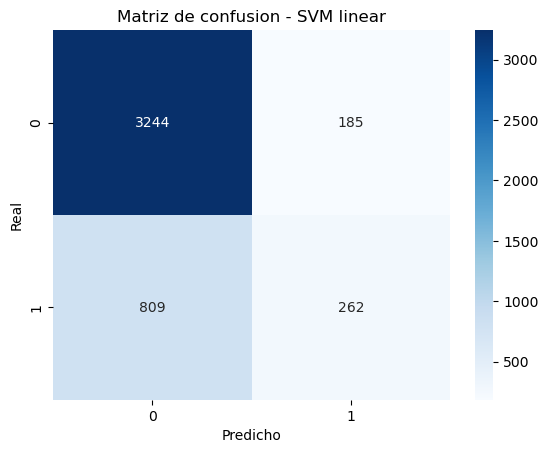

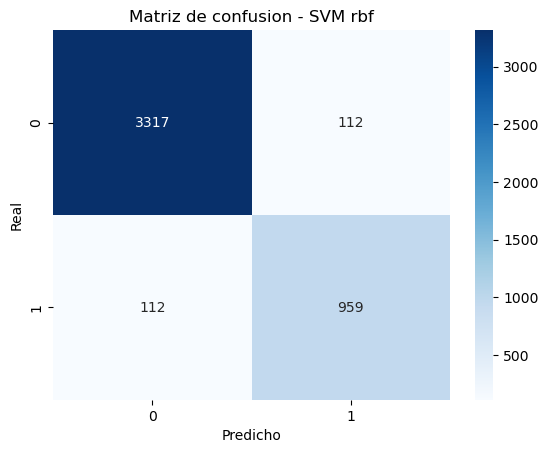

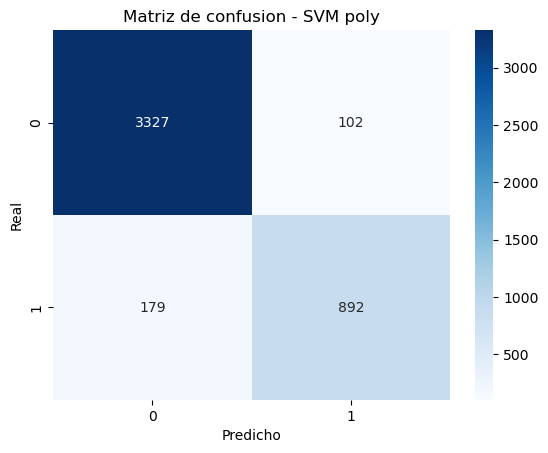

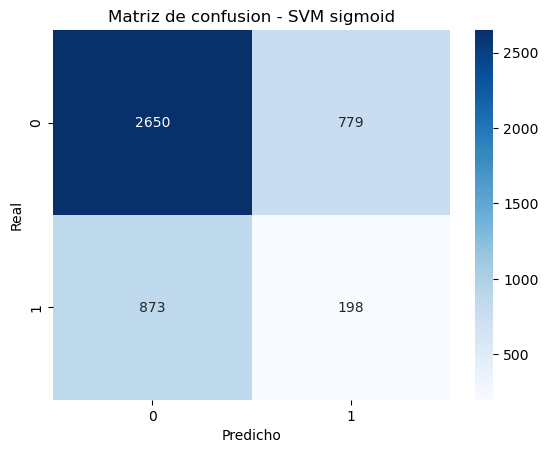

In [59]:
for name, clf in models.items():
    clf.fit(X_train_sc, y_train)
    y_pred = clf.predict(X_test_sc)
    cm = confusion_matrix(y_test, y_pred)

    plt.figure()
    sns.heatmap(cm, annot= True, fmt='d', cmap='Blues')
    plt.title(f'Matriz de confusion - SVM {name}')
    plt.xlabel('Predicho')
    plt.ylabel('Real')
    plt.show()

¿Cuál modelo elegir y por qué?
*RBF*
Comparando los cuatro kernels del SVM, el modelo con Kernel RBF resultó el más adecuado porque logra el mejor balance general entre desempeño y detección de la clase de interés. Aunque el kernel polinomial también presenta buen rendimiento, RBF alcanza una exactitud muy cercana a 0.95 y, más importante, mantiene valores altos y equilibrados de precisión, recall y f1-score para la clase 1 (~0.90), reduciendo tanto falsos positivos como falsos negativos (matriz de confusión prácticamente simétrica). En cambio, el kernell lineal presenta baja sensibilidad para la clase 1 (recall ~0.24), lo que implica que se le escapan muchos empleados que si abandonan la empresa, y el kernell sigmoid muestra el peor comportamiento global. Por ello. el RBF es el kernel que mejor se ajusta al problema y al objetivo de identificar correctamente a los empleados con mayor probabilidad de salida.

In [62]:
nuevo = pd.DataFrame([{
    'satisfaction_level': 0.5,
    'last_evaluation': 0.75,
    'number_project': 4,
    'average_monthly_hours': 200,
    'time_spend_company': 4,
    'work_accident': 0,
    'promotion_last_5years': 0,
    'sales': 'sales',
    'salary': 'medium'
}])

In [64]:
nuevo.isna().sum()

satisfaction_level       0
last_evaluation          0
number_project           0
average_monthly_hours    0
time_spend_company       0
work_accident            0
promotion_last_5years    0
sales                    0
salary                   0
dtype: int64

In [68]:
nuevo2 = pd.get_dummies(nuevo, columns= ['sales', 'salary'], drop_first= True)

In [70]:
nuevo2 = nuevo2.reindex(columns= X.columns, fill_value= 0)

In [72]:
nuevo_sc = scaler.transform(nuevo2)

In [76]:
best_model = models['rbf']
best_model.fit(X_train_sc, y_train)

pred = best_model.predict(nuevo_sc)[0]
proba = best_model.predict_proba(nuevo_sc)[0,1]

print('Predicción (1=se va, 0= se queda):', pred)
print('Probabilidad de que se vaya:', proba)

Predicción (1=se va, 0= se queda): 0
Probabilidad de que se vaya: 0.0006821365798729119
